# Model Attempt 2 — EfficientNet-B0 Gaze Estimation
**Architecture**: EfficientNet-B0 → theta/phi (radians)  
**Labels**: θ = arcsin(−gy), φ = atan2(−gx, −gz), normalised to [−1, 1]  
**Data**: MPIIGaze Normalised (real, right eyes only) + UnityEyes2 (synthetic, right eye)  
**Loss**: Huber Loss (δ = 0.1)  
**Split**: 70 / 15 / 15 (train / val / test), seed 42

---
### Workflow
1. Mount Drive & install deps  
2. Load CSVs → sample 12K real + 12K synthetic (right eye only)  
3. Dataset class with augmentation  
4. EfficientNet-B0 model definition  
5. Training loop with early stopping  
6. **Ratio Experiment** — sweep synthetic fraction 0 % → 100 % (keeps total = 24 K)  
7. Evaluation — MAE°, RMSE°, R², per-axis analysis  
8. Sectional accuracy — 4 × 3 imaginary 1080p display grid  
9. Export best model to ONNX

## 1. Environment Setup

In [1]:
# Install the notebook packages once.
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "timm", "scipy", "torchmetrics"], check=True)

from google.colab import drive
drive.mount('/content/drive')
# drive.mount("/content/drive", force_remount=True)
import os, zipfile, shutil

DRIVE_ROOT     = '/content/drive/MyDrive/FYP_3DML'
UNITY_ZIP      = f'{DRIVE_ROOT}/unity_crops.zip'
MPII_ZIP       = f'{DRIVE_ROOT}/mpii_crops.zip'
UNITY_CSV      = f'{DRIVE_ROOT}/unity_labels.csv'
MPII_CSV       = f'{DRIVE_ROOT}/mpii_labels.csv'

EXTRACT_UNITY  = '/content/crops/unity'
EXTRACT_MPII   = '/content/crops/mpii'

# Copy and extract only when the data is still missing.
def maybe_unzip(zip_path, dest):
    if os.path.exists(dest):
        print(f"Already extracted: {dest}")
        return
    local_zip = f"/content/{os.path.basename(zip_path)}"
    if not os.path.exists(local_zip):
        print(f"Copying {os.path.basename(zip_path)} from Drive to local disk ...")
        shutil.copy2(zip_path, local_zip)
        print(f"  Copied ({os.path.getsize(local_zip)/1e6:.0f} MB)")
    print(f"Unzipping {os.path.basename(local_zip)} ...")
    with zipfile.ZipFile(local_zip, 'r') as z:
        z.extractall(dest)
    os.remove(local_zip)
    print("  Done.")

maybe_unzip(UNITY_ZIP, EXTRACT_UNITY)
maybe_unzip(MPII_ZIP, EXTRACT_MPII)
print("Drive mounted and data ready.")

Mounted at /content/drive
Copying unity_crops.zip from Drive to local disk ...
  Copied (82 MB)
Unzipping unity_crops.zip ...
  Done.
Copying mpii_crops.zip from Drive to local disk ...
  Copied (2094 MB)
Unzipping mpii_crops.zip ...
  Done.
Drive mounted and data ready.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
import glob, os, pandas as pd

# Check the extracted files and a few CSV paths.
for label, root in [('MPII', '/content/crops/mpii'), ('Unity', '/content/crops/unity')]:
    files = glob.glob(f'{root}/**/*', recursive=True)
    imgs  = [f for f in files if f.endswith('.jpg')]
    print(f"\n{label}: {root}")
    print(f"  Total files  : {len(files)}")
    print(f"  Total images : {len(imgs)}")
    print("  First 5 paths:")
    for p in imgs[:5]:
        print(f"    {p}")

print("\n\nMPII CSV filepath samples:")
_df = pd.read_csv(MPII_CSV, nrows=3)
print(_df[['filepath']].to_string())

print("\nUnity CSV filepath samples:")
_df2 = pd.read_csv(UNITY_CSV, nrows=3)
print(_df2[['filepath']].to_string())



MPII: /content/crops/mpii
  Total files  : 427307
  Total images : 427306
  First 5 paths:
    /content/crops/mpii/mpii/mpii_p00_day17_0105_left.jpg
    /content/crops/mpii/mpii/mpii_p06_day15_0025_right.jpg
    /content/crops/mpii/mpii/mpii_p06_day03_0018_left.jpg
    /content/crops/mpii/mpii/mpii_p08_day41_0401_left.jpg
    /content/crops/mpii/mpii/mpii_p03_day51_0375_right.jpg

Unity: /content/crops/unity
  Total files  : 12913
  Total images : 12912
  First 5 paths:
    /content/crops/unity/unity_gs/unity_2034.jpg
    /content/crops/unity/unity_gs/unity_21530.jpg
    /content/crops/unity/unity_gs/unity_13910.jpg
    /content/crops/unity/unity_gs/unity_3858.jpg
    /content/crops/unity/unity_gs/unity_7408.jpg


MPII CSV filepath samples:
                                                                               filepath
0  D:/projects/academical/eyedata_FYP/3d/preprocess1/mpii\mpii_p00_day01_0001_right.jpg
1  D:/projects/academical/eyedata_FYP/3d/preprocess1/mpii\mpii_p00_day01

## 2. Imports & Config

In [4]:
import math, os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import timm

# Fix the random seeds so runs stay comparable.
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Main training settings.
CROP_SIZE    = 128
BATCH_SIZE   = 64
LR           = 3e-4
EPOCHS       = 18
PATIENCE     = 999
HUBER_DELTA  = 0.1
WEIGHT_DECAY = 1e-3

# These limits are used when labels are scaled.
THETA_MAX = math.radians(25)
PHI_MAX   = math.radians(35)

MAX_REAL    = 12_000
MAX_SYNTH   = 12_000

# These settings are only for the ratio test.
RATIO_EPOCHS   = 20
RATIO_PATIENCE = 4

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")


Device: cpu


## 3. Data Loading
Load both CSVs, keep **right eyes only**, cap at 12 K each, then merge. Filepaths are rebased to the local Colab extraction directories.

MPII  images on disk : 427306
Unity images on disk :  12912

Real    :  12000  samples
Synthetic: 12000  samples
Total   :  24000  samples

Theta range: -25.0° -> 25.0°
Phi   range: -35.0° -> 35.0°

Sample path : /content/crops/mpii/mpii/mpii_p05_day07_0588_right.jpg
File exists : True


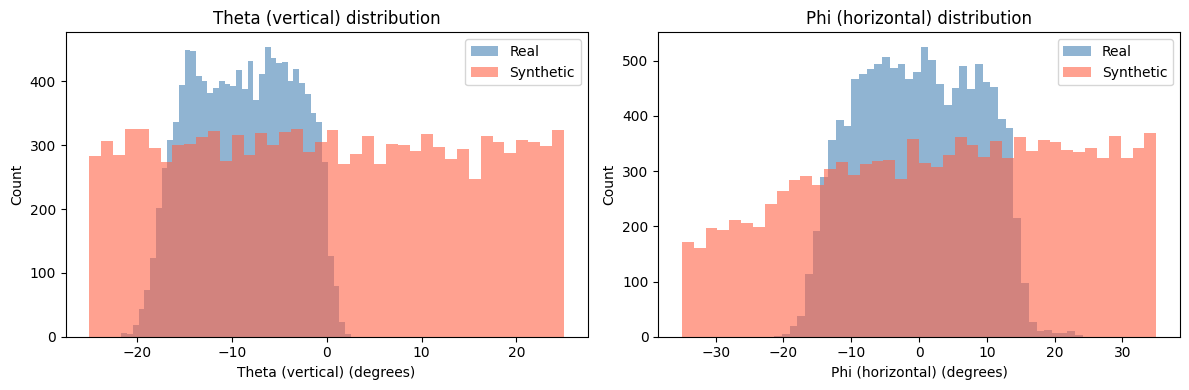

In [5]:
import glob

# Swap the original folder with the local extract folder.
def rebase_path(old_path: str, new_root: str) -> str:
    fname = old_path.replace('\\', '/').split('/')[-1]
    return os.path.join(new_root, fname)

IMAGES_MPII  = f'{EXTRACT_MPII}/mpii'
IMAGES_UNITY = f'{EXTRACT_UNITY}/unity_gs'

mpii_on_disk  = {os.path.basename(p) for p in glob.glob(f'{IMAGES_MPII}/*.jpg')}
unity_on_disk = {os.path.basename(p) for p in glob.glob(f'{IMAGES_UNITY}/*.jpg')}
print(f"MPII  images on disk : {len(mpii_on_disk):>6}")
print(f"Unity images on disk : {len(unity_on_disk):>6}")

df_real = pd.read_csv(MPII_CSV)
df_real = df_real[df_real['side'] == 'right'].copy()
df_real['_fname'] = df_real['filepath'].apply(lambda p: p.replace('\\', '/').split('/')[-1])
df_real = df_real[df_real['_fname'].isin(mpii_on_disk)].drop(columns='_fname')
df_real = df_real.sample(n=min(MAX_REAL, len(df_real)), random_state=SEED).reset_index(drop=True)
df_real['filepath'] = df_real['filepath'].apply(lambda p: rebase_path(p, IMAGES_MPII))

df_synth = pd.read_csv(UNITY_CSV)
df_synth['_fname'] = df_synth['filepath'].apply(lambda p: p.replace('\\', '/').split('/')[-1])
df_synth = df_synth[df_synth['_fname'].isin(unity_on_disk)].drop(columns='_fname')
df_synth = df_synth.sample(n=min(MAX_SYNTH, len(df_synth)), random_state=SEED).reset_index(drop=True)
df_synth['filepath'] = df_synth['filepath'].apply(lambda p: rebase_path(p, IMAGES_UNITY))

df_all = pd.concat([df_real, df_synth], ignore_index=True)
df_all = df_all.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nReal    : {len(df_real):>6}  samples")
print(f"Synthetic: {len(df_synth):>5}  samples")
print(f"Total   : {len(df_all):>6}  samples")
print(f"\nTheta range: {np.degrees(df_all.theta.min()):.1f}° -> {np.degrees(df_all.theta.max()):.1f}°")
print(f"Phi   range: {np.degrees(df_all.phi.min()):.1f}° -> {np.degrees(df_all.phi.max()):.1f}°")

_sample = df_all['filepath'].iloc[0]
print(f"\nSample path : {_sample}")
print(f"File exists : {os.path.exists(_sample)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ['theta', 'phi'], ['Theta (vertical)', 'Phi (horizontal)']):
    ax.hist(np.degrees(df_real[col]),  bins=40, alpha=0.6, label='Real',      color='steelblue')
    ax.hist(np.degrees(df_synth[col]), bins=40, alpha=0.6, label='Synthetic', color='tomato')
    ax.set_xlabel(f'{label} (degrees)'); ax.set_ylabel('Count')
    ax.set_title(f'{label} distribution'); ax.legend()
plt.tight_layout(); plt.show()


## 4. Dataset Class & Train/Val/Test Split
70 / 15 / 15 split with stratified-like shuffling. Augmentation applied only to the training split.

In [6]:
# This dataset keeps image loading and label scaling in one place.
class GazeDataset(Dataset):
    """Eye-crop dataset returning (image_tensor, [theta_n, phi_n])."""

    # Augmentation for training split
    TRAIN_TF = T.Compose([
        T.RandomHorizontalFlip(p=0.0),
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
        T.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
    ])

    EVAL_TF = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
    ])

    def __init__(self, df: pd.DataFrame, augment: bool = False):
        self.df      = df.reset_index(drop=True)
        self.augment = augment
        self.tf      = self.TRAIN_TF if augment else self.EVAL_TF

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB').resize((CROP_SIZE, CROP_SIZE))
        img = self.tf(img)

        theta_n = float(row['theta']) / THETA_MAX
        phi_n   = float(row['phi'])   / PHI_MAX
        label   = torch.tensor([theta_n, phi_n], dtype=torch.float32)
        return img, label


def make_splits(df, train_frac=0.70, val_frac=0.15):
    n     = len(df)
    n_tr  = int(n * train_frac)
    n_val = int(n * val_frac)
    idx   = list(range(n))

    train_idx = idx[:n_tr]
    val_idx   = idx[n_tr : n_tr + n_val]
    test_idx  = idx[n_tr + n_val:]
    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = make_splits(df_all)

full_ds    = GazeDataset(df_all, augment=False)
train_ds   = GazeDataset(df_all.iloc[train_idx], augment=True)
val_ds     = GazeDataset(df_all.iloc[val_idx],   augment=False)
test_ds    = GazeDataset(df_all.iloc[test_idx],  augment=False)
test_df    = df_all.iloc[test_idx].reset_index(drop=True)   # keep for ratio experiment

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds):>6}  |  Val: {len(val_ds):>5}  |  Test: {len(test_ds):>5}")

Train:  16800  |  Val:  3600  |  Test:  3600


## 5. Model — EfficientNet-B0
Pretrained backbone, head replaced with a two-output regression head → `Tanh()` → [−1, 1].

In [11]:
# This builds the same model used for training and export.
def build_model() -> nn.Module:
    model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
    in_features = model.num_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(256, 2),
        nn.Tanh()
    )
    return model


model = build_model().to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

criterion = nn.HuberLoss(delta=HUBER_DELTA)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

Total params    : 4,335,998
Trainable params: 4,335,998


## 5b. Training Time Estimate
Runs 20 batches through a forward + backward pass and extrapolates. **Run this before committing to full training** — if one epoch is too slow, reduce `MAX_REAL`, `MAX_SYNTH`, or `BATCH_SIZE` above and re-run cell 3 & 4.

In [ ]:
import time

BENCHMARK_BATCHES = 20

# This gives a quick time estimate before full training.
model.train()
_opt = torch.optim.SGD(model.parameters(), lr=1e-3)

times = []
for i, (imgs, labels) in enumerate(train_loader):
    if i >= BENCHMARK_BATCHES:
        break
    t0 = time.perf_counter()
    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
    loss = criterion(model(imgs), labels)
    _opt.zero_grad(); loss.backward(); _opt.step()
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    times.append(time.perf_counter() - t0)

del _opt
model.eval()

avg_batch_s  = sum(times) / len(times)
batches_per_epoch = math.ceil(len(train_ds) / BATCH_SIZE)
epoch_s      = avg_batch_s * batches_per_epoch
full_train_s = epoch_s * EPOCHS
n_ratio_runs = len(SYNTH_FRACTIONS)

print(f"Batch size          : {BATCH_SIZE}")
print(f"Batches per epoch   : {batches_per_epoch}")
print(f"Avg time / batch    : {avg_batch_s*1000:.1f} ms")
print()
print(f"Est. time / epoch   : {epoch_s:.0f}s  ({epoch_s/60:.1f} min)")
print(f"Est. full {EPOCHS} epochs : {full_train_s/60:.0f} min  ({full_train_s/3600:.1f} hr)")
print()

if epoch_s > 300:
    rec_samples = int((len(train_ds) / epoch_s) * 120)
    print(f"⚠  Epoch > 5 min. Consider reducing MAX_REAL/MAX_SYNTH.")
    print(f"   For ~2 min epochs, use ~{rec_samples:,} total training samples.")
elif epoch_s > 120:
    print(f"⚠  Epoch ~{epoch_s/60:.1f} min. Manageable, but ratio experiment (×{n_ratio_runs}) will take ~{epoch_s/60*RATIO_EPOCHS*n_ratio_runs/60:.1f} hr.")
else:
    print(f"✓  Epoch time looks good. Full training + ratio experiment should complete in ~{(full_train_s + epoch_s*RATIO_EPOCHS*n_ratio_runs)/3600:.1f} hr.")


Batch size          : 64
Batches per epoch   : 263
Avg time / batch    : 127.6 ms

Est. time / epoch   : 34s  (0.6 min)
Est. full 30 epochs : 17 min  (0.3 hr)

✓  Epoch time looks good. Full training + ratio experiment should complete in ~1.4 hr.


## 6. Training Loop
Trains with early stopping on validation loss. Saves the best checkpoint to Drive.

Ep   1/18  train=0.0126  val=0.0068  lr=2.98e-04  ✓ saved  (34.7s)
Ep   2/18  train=0.0067  val=0.0052  lr=2.91e-04  ✓ saved  (33.3s)
Ep   3/18  train=0.0053  val=0.0042  lr=2.80e-04  ✓ saved  (33.5s)
Ep   4/18  train=0.0046  val=0.0036  lr=2.65e-04  ✓ saved  (33.4s)
Ep   5/18  train=0.0041  val=0.0034  lr=2.47e-04  ✓ saved  (33.8s)
Ep   6/18  train=0.0037  val=0.0034  lr=2.25e-04  patience 1/999  (33.1s)
Ep   7/18  train=0.0034  val=0.0030  lr=2.02e-04  ✓ saved  (33.3s)
Ep   8/18  train=0.0031  val=0.0029  lr=1.76e-04  ✓ saved  (33.2s)
Ep   9/18  train=0.0028  val=0.0030  lr=1.50e-04  patience 1/999  (33.1s)
Ep  10/18  train=0.0027  val=0.0033  lr=1.25e-04  patience 2/999  (33.4s)
Ep  11/18  train=0.0025  val=0.0027  lr=9.94e-05  ✓ saved  (33.7s)
Ep  12/18  train=0.0022  val=0.0026  lr=7.58e-05  ✓ saved  (33.3s)
Ep  13/18  train=0.0022  val=0.0026  lr=5.44e-05  ✓ saved  (33.3s)
Ep  14/18  train=0.0020  val=0.0025  lr=3.60e-05  ✓ saved  (34.0s)
Ep  15/18  train=0.0019  val=0.0023  lr=2

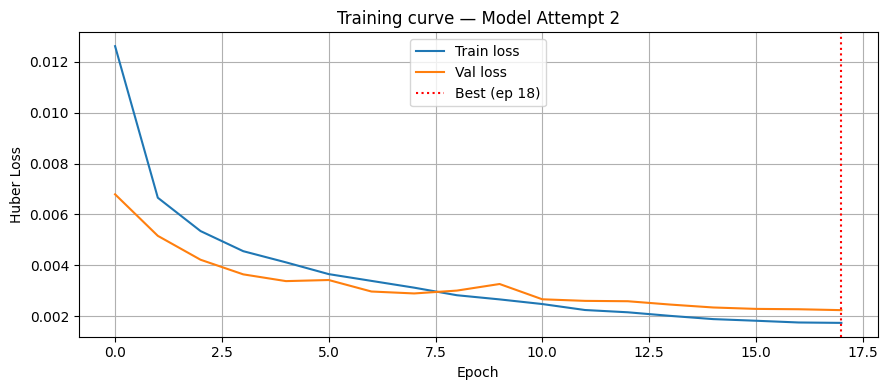


Best val loss : 0.00224  (epoch 18)
Checkpoint saved to: /content/drive/MyDrive/FYP_3DML/gaze_model_attempt2_best.pth


In [ ]:
CKPT_PATH = f'{DRIVE_ROOT}/gaze_model_attempt2_best.pth'

# This runs one full pass for training or validation.
def run_epoch(loader, model, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, n = 0.0, 0
    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = model(imgs)
            loss  = criterion(preds, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(imgs)
            n          += len(imgs)
    return total_loss / n


history = {'train': [], 'val': []}
best_val, best_epoch, patience_counter = float('inf'), 0, 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss  = run_epoch(train_loader, model, criterion, optimizer)
    val_loss = run_epoch(val_loader,   model, criterion)
    scheduler.step()

    history['train'].append(tr_loss)
    history['val'].append(val_loss)

    improved = val_loss < best_val
    if improved:
        best_val = val_loss
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), CKPT_PATH)
        tag = '✓ saved'
    else:
        patience_counter += 1
        tag = f'patience {patience_counter}/{PATIENCE}'

    print(f"Ep {epoch:3d}/{EPOCHS}  "
          f"train={tr_loss:.4f}  val={val_loss:.4f}  "
          f"lr={scheduler.get_last_lr()[0]:.2e}  "
          f"{tag}  ({time.time()-t0:.1f}s)")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

plt.figure(figsize=(9, 4))
plt.plot(history['train'], label='Train loss')
plt.plot(history['val'],   label='Val loss')
plt.axvline(best_epoch - 1, color='red', linestyle=':', linewidth=1.5, label=f'Best (ep {best_epoch})')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss')
plt.title('Training curve — Model Attempt 2'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

print(f"\nBest val loss : {best_val:.5f}  (epoch {best_epoch})")
print(f"Checkpoint saved to: {CKPT_PATH}")


## 7. Evaluation — Core Metrics
Load the best checkpoint and evaluate on the held-out test set.  
Reports **MAE°**, **RMSE°**, **R²** for theta (vertical) and phi (horizontal) separately, plus combined angular error.

────────────────────────────────────────────────────
Test set metrics (best model)
────────────────────────────────────────────────────
  Theta   MAE=1.331°  RMSE=1.862°  R²=0.9754
  Phi     MAE=1.825°  RMSE=3.361°  R²=0.9508
  Angular combined  MAE=2.513°  RMSE=3.842°
────────────────────────────────────────────────────


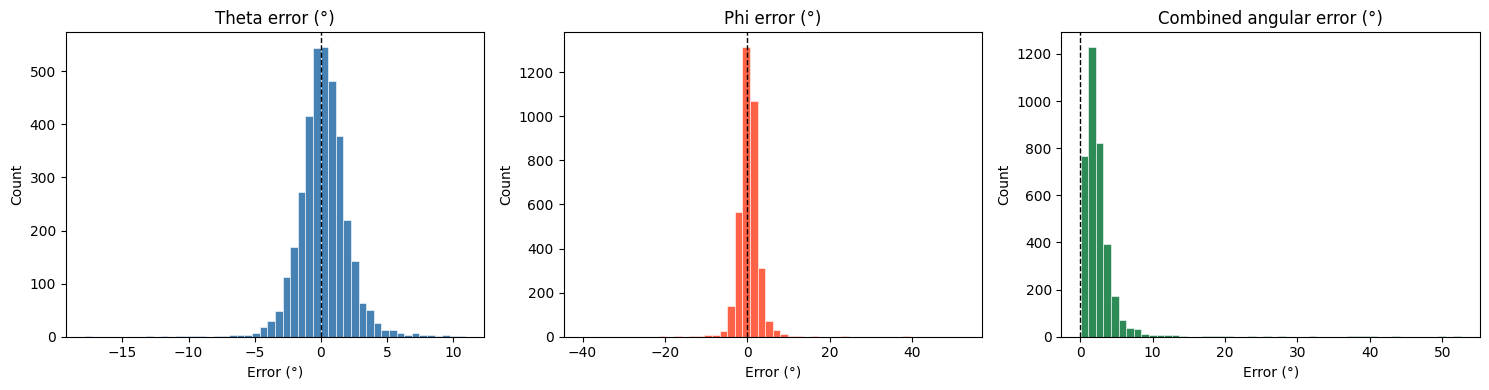

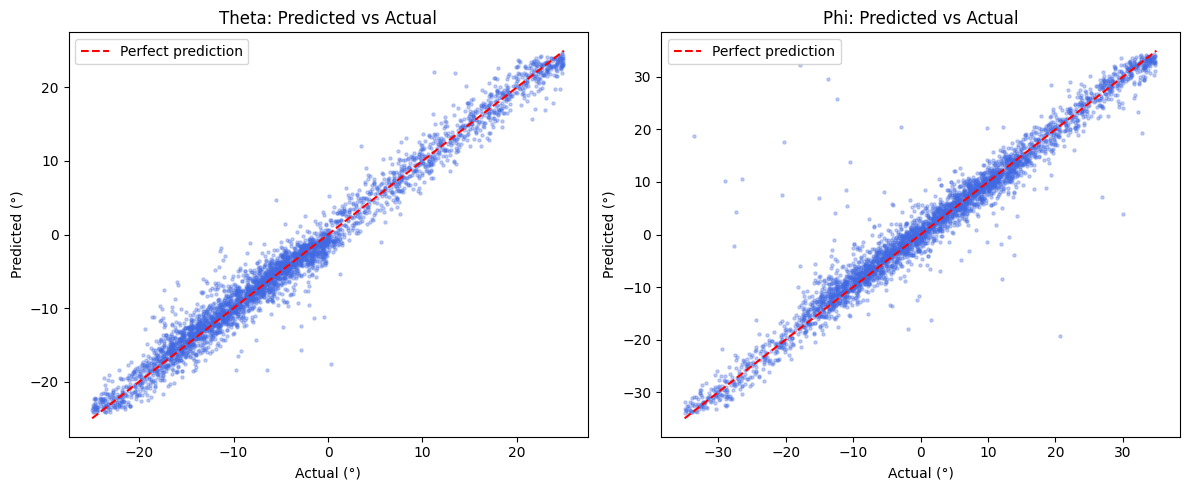

In [ ]:
from sklearn.metrics import r2_score

model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(DEVICE)).cpu()
        all_preds.append(preds); all_labels.append(labels)

preds_n  = torch.cat(all_preds).numpy()
labels_n = torch.cat(all_labels).numpy()

# Convert predictions back to degrees for reporting.
preds_deg  = preds_n  * np.array([math.degrees(THETA_MAX), math.degrees(PHI_MAX)])
labels_deg = labels_n * np.array([math.degrees(THETA_MAX), math.degrees(PHI_MAX)])

theta_err = preds_deg[:, 0] - labels_deg[:, 0]
phi_err   = preds_deg[:, 1] - labels_deg[:, 1]
angular_err = np.sqrt(theta_err**2 + phi_err**2)

# This keeps the per-axis metric printout in one place.
def metrics(err, axis_name):
    mae  = np.abs(err).mean()
    rmse = np.sqrt((err**2).mean())
    r2   = r2_score(labels_deg[:, 0 if axis_name == 'Theta' else 1],
                    preds_deg[:,  0 if axis_name == 'Theta' else 1])
    print(f"  {axis_name:6s}  MAE={mae:.3f}°  RMSE={rmse:.3f}°  R²={r2:.4f}")
    return mae, rmse, r2

print("─" * 52)
print("Test set metrics (best model)")
print("─" * 52)
t_mae, t_rmse, t_r2 = metrics(theta_err, 'Theta')
p_mae, p_rmse, p_r2 = metrics(phi_err,   'Phi')
print(f"  Angular combined  MAE={angular_err.mean():.3f}°  RMSE={np.sqrt((angular_err**2).mean()):.3f}°")
print("─" * 52)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, err, title, color in zip(
    axes,
    [theta_err, phi_err, angular_err],
    ['Theta error (°)', 'Phi error (°)', 'Combined angular error (°)'],
    ['steelblue', 'tomato', 'seagreen']
):
    ax.hist(err, bins=50, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(title); ax.set_xlabel('Error (°)'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, true, title in zip(
    axes,
    [preds_deg[:, 0], preds_deg[:, 1]],
    [labels_deg[:, 0], labels_deg[:, 1]],
    ['Theta: Predicted vs Actual', 'Phi: Predicted vs Actual']
):
    ax.scatter(true, pred, alpha=0.3, s=5, color='royalblue')
    lim = max(abs(np.array([true, pred]).flatten()).max(), 1)
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual (°)'); ax.set_ylabel('Predicted (°)')
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

────────────────────────────────────────────────────
Threshold accuracy (angular error)
────────────────────────────────────────────────────
  Within  2°  : 50.9%
  Within  5°  : 93.4%
  Within 10°  : 98.5%

────────────────────────────────────────────────────
Robust statistics
────────────────────────────────────────────────────
  Median angular error : 1.967°
  95th percentile      : 5.561°
  Median theta error   : 1.012°
  Median phi error     : 1.254°

────────────────────────────────────────────────────
Pixel error on 1920×1080 display @ 600 mm
────────────────────────────────────────────────────
  Theta  MAE  : 86.6 px
  Phi    MAE  : 120.8 px
  Combined MAE: 165.6 px
  Combined 95p: 363.0 px

────────────────────────────────────────────────────
Angular MAE by screen quadrant (gaze direction)
────────────────────────────────────────────────────
  Top-Left    (θ<0, φ<0): 2.544°  (n=1285)
  Top-Right   (θ<0, φ>0): 2.216°  (n=1362)
  Bottom-Left (θ>0, φ<0): 3.424°  (n=389)
  Bottom-

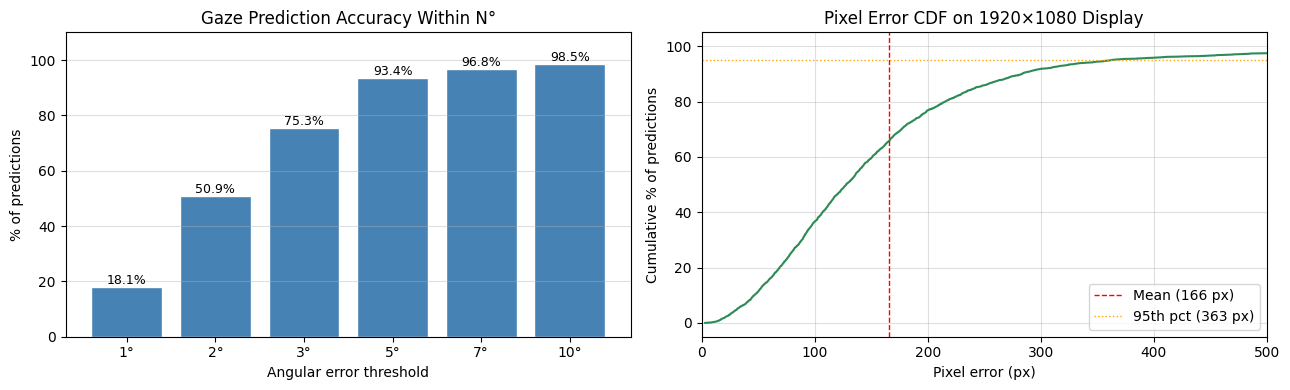

In [ ]:
print("─" * 52)
print("Threshold accuracy (angular error)")
print("─" * 52)
for thresh in [2, 5, 10]:
    pct = (angular_err < thresh).mean() * 100
    print(f"  Within {thresh:2d}°  : {pct:.1f}%")
print()

# ── 2. Median & 95th percentile ───────────────────────────────────────────────
print("─" * 52)
print("Robust statistics")
print("─" * 52)
print(f"  Median angular error : {np.median(angular_err):.3f}°")
print(f"  95th percentile      : {np.percentile(angular_err, 95):.3f}°")
print(f"  Median theta error   : {np.median(np.abs(theta_err)):.3f}°")
print(f"  Median phi error     : {np.median(np.abs(phi_err)):.3f}°")
print()

# This turns angle error into approximate screen pixel error.
SCREEN_PX_W  = 1920
SCREEN_PX_H  = 1080
SCREEN_MM_W  = 309.0
SCREEN_MM_H  = 174.0
DIST_MM_EVAL = 600.0

px_per_mm_w = SCREEN_PX_W / SCREEN_MM_W
px_per_mm_h = SCREEN_PX_H / SCREEN_MM_H

# Convert angular error to mm displacement at viewing distance, then to pixels
theta_mm  = np.tan(np.radians(np.abs(theta_err))) * DIST_MM_EVAL
phi_mm    = np.tan(np.radians(np.abs(phi_err)))   * DIST_MM_EVAL
theta_px  = theta_mm * px_per_mm_h
phi_px    = phi_mm   * px_per_mm_w
combined_px = np.sqrt(theta_px**2 + phi_px**2)

print("─" * 52)
print("Pixel error on 1920×1080 display @ 600 mm")
print("─" * 52)
print(f"  Theta  MAE  : {theta_px.mean():.1f} px")
print(f"  Phi    MAE  : {phi_px.mean():.1f} px")
print(f"  Combined MAE: {combined_px.mean():.1f} px")
print(f"  Combined 95p: {np.percentile(combined_px, 95):.1f} px")
print()

print("─" * 52)
print("Angular MAE by screen quadrant (gaze direction)")
print("─" * 52)
quadrants = {
    'Top-Left    (θ<0, φ<0)': (labels_deg[:, 0] < 0) & (labels_deg[:, 1] < 0),
    'Top-Right   (θ<0, φ>0)': (labels_deg[:, 0] < 0) & (labels_deg[:, 1] > 0),
    'Bottom-Left (θ>0, φ<0)': (labels_deg[:, 0] > 0) & (labels_deg[:, 1] < 0),
    'Bottom-Right(θ>0, φ>0)': (labels_deg[:, 0] > 0) & (labels_deg[:, 1] > 0),
}
for name, mask in quadrants.items():
    if mask.sum() > 0:
        q_mae = angular_err[mask].mean()
        print(f"  {name}: {q_mae:.3f}°  (n={mask.sum()})")

thresholds = [1, 2, 3, 5, 7, 10]
pcts = [(angular_err < t).mean() * 100 for t in thresholds]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar([f"{t}°" for t in thresholds], pcts, color='steelblue', edgecolor='white')
for i, (t, p) in enumerate(zip(thresholds, pcts)):
    axes[0].text(i, p + 1, f"{p:.1f}%", ha='center', fontsize=9)
axes[0].set_ylim(0, 110)
axes[0].set_xlabel('Angular error threshold')
axes[0].set_ylabel('% of predictions')
axes[0].set_title('Gaze Prediction Accuracy Within N°')
axes[0].grid(axis='y', alpha=0.4)

sorted_px = np.sort(combined_px)
cdf = np.arange(1, len(sorted_px) + 1) / len(sorted_px) * 100
axes[1].plot(sorted_px, cdf, color='seagreen', linewidth=1.5)
axes[1].axvline(combined_px.mean(), color='red', linestyle='--', linewidth=1,
                label=f'Mean ({combined_px.mean():.0f} px)')
axes[1].axhline(95, color='orange', linestyle=':', linewidth=1,
                label=f'95th pct ({np.percentile(combined_px, 95):.0f} px)')
axes[1].set_xlabel('Pixel error (px)')
axes[1].set_ylabel('Cumulative % of predictions')
axes[1].set_title('Pixel Error CDF on 1920×1080 Display')
axes[1].legend(); axes[1].grid(alpha=0.4)
axes[1].set_xlim(0, min(np.percentile(combined_px, 99) * 1.1, 500))

plt.tight_layout(); plt.show()

## 8. Sectional Accuracy — 4 × 3 Imaginary Display Grid
Maps gaze angles to a 1920 × 1080 display at 600 mm viewing distance, divides it into a 4-column × 3-row grid (12 zones), and computes per-zone classification accuracy.  
This mirrors the confusion-matrix test described in the thesis (Chapter 8).

Overall zone accuracy (4×3 grid): 80.92%

  Zone R1C1 : 82.9%  (n=639)
  Zone R1C2 : 75.6%  (n=479)
  Zone R1C3 : 73.3%  (n=434)
  Zone R1C4 : 90.0%  (n=737)
  Zone R2C1 : 62.8%  (n=137)
  Zone R2C2 : 64.8%  (n=91)
  Zone R2C3 : 60.6%  (n=99)
  Zone R2C4 : 66.5%  (n=164)
  Zone R3C1 : 90.7%  (n=246)
  Zone R3C2 : 66.7%  (n=84)
  Zone R3C3 : 70.5%  (n=105)
  Zone R3C4 : 96.9%  (n=385)


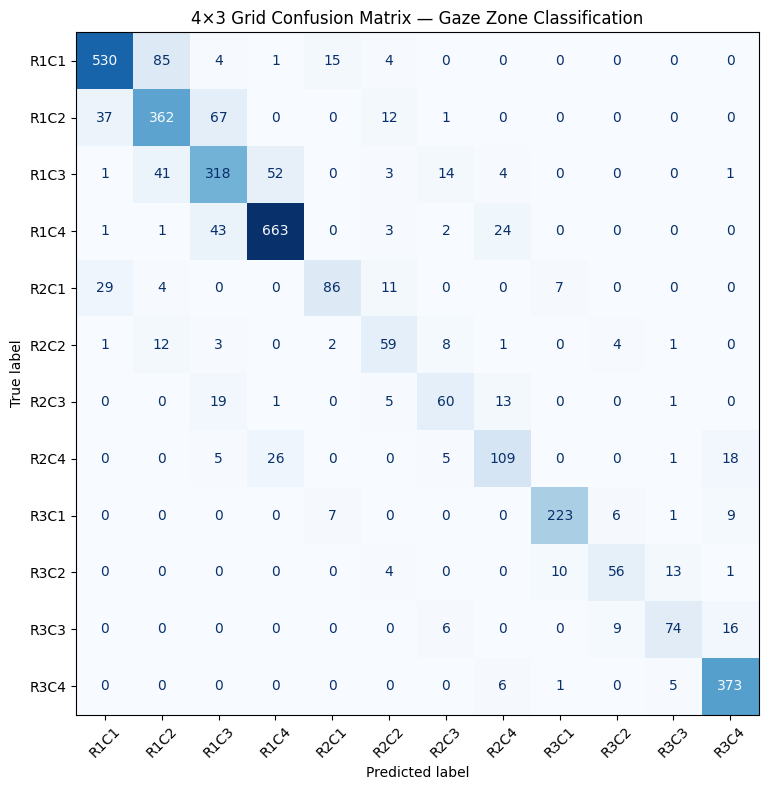

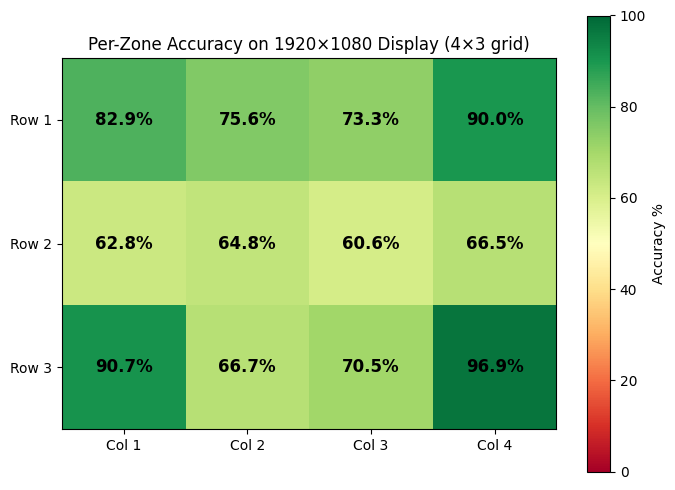

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SCREEN_W_MM   = 309.0
SCREEN_H_MM   = 174.0
DIST_MM       = 600.0
GRID_COLS     = 4
GRID_ROWS     = 3
N_ZONES       = GRID_COLS * GRID_ROWS

PHI_EDGE   = math.atan2(SCREEN_W_MM / 2, DIST_MM)
THETA_EDGE = math.atan2(SCREEN_H_MM / 2, DIST_MM)

phi_bins   = np.linspace(-PHI_EDGE,   PHI_EDGE,   GRID_COLS + 1)
theta_bins = np.linspace(-THETA_EDGE, THETA_EDGE, GRID_ROWS + 1)

# This maps gaze angles into the display grid.
def angle_to_zone(theta_rad: np.ndarray, phi_rad: np.ndarray) -> np.ndarray:
    col = np.digitize(phi_rad,   phi_bins)   - 1
    row = np.digitize(theta_rad, theta_bins) - 1
    col = np.clip(col, 0, GRID_COLS - 1)
    row = np.clip(row, 0, GRID_ROWS - 1)
    return row * GRID_COLS + col

true_zones  = angle_to_zone(np.radians(labels_deg[:, 0]), np.radians(labels_deg[:, 1]))
pred_zones  = angle_to_zone(np.radians(preds_deg[:,  0]), np.radians(preds_deg[:,  1]))

overall_acc = (true_zones == pred_zones).mean() * 100
print(f"Overall zone accuracy (4×3 grid): {overall_acc:.2f}%\n")

zone_labels = [f"R{r+1}C{c+1}" for r in range(GRID_ROWS) for c in range(GRID_COLS)]
per_zone_acc = []
for z in range(N_ZONES):
    mask = true_zones == z
    if mask.sum() == 0:
        per_zone_acc.append(float('nan'))
    else:
        per_zone_acc.append((pred_zones[mask] == z).mean() * 100)
    print(f"  Zone {zone_labels[z]:5s}: {per_zone_acc[-1]:.1f}%  (n={mask.sum()})")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(true_zones, pred_zones, labels=list(range(N_ZONES)))
fig, ax = plt.subplots(figsize=(11, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=zone_labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title('4×3 Grid Confusion Matrix — Gaze Zone Classification')
plt.tight_layout(); plt.show()

# ── Heatmap of per-zone accuracy on display layout ───────────────────────────
acc_grid = np.array(per_zone_acc).reshape(GRID_ROWS, GRID_COLS)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(acc_grid, cmap='RdYlGn', vmin=0, vmax=100)
for r in range(GRID_ROWS):
    for c in range(GRID_COLS):
        ax.text(c, r, f"{acc_grid[r, c]:.1f}%", ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='black' if acc_grid[r, c] > 40 else 'white')
ax.set_xticks(range(GRID_COLS)); ax.set_xticklabels([f'Col {c+1}' for c in range(GRID_COLS)])
ax.set_yticks(range(GRID_ROWS)); ax.set_yticklabels([f'Row {r+1}' for r in range(GRID_ROWS)])
ax.set_title('Per-Zone Accuracy on 1920×1080 Display (4×3 grid)')
plt.colorbar(im, ax=ax, label='Accuracy %')
plt.tight_layout(); plt.show()

## 9. Synthetic-to-Real Ratio Experiment
Trains 6 models on the **same fixed test set**, sweeping the synthetic fraction of training data from 0 % (all real) to 100 % (all synthetic).  
Total training samples = 16 800 (70 % of 24 K) in each run.  
Reports test MAE° and zone accuracy for each ratio — answers "how much synthetic data is optimal?"


Ratio: 30% synthetic / 70% real
  ep   5  tr=0.0039  val=0.0040
  ep  10  tr=0.0025  val=0.0032
  ep  15  tr=0.0018  val=0.0026
  ep  20  tr=0.0015  val=0.0025
  → Angular MAE=1.932°  Zone acc=85.8%

Ratio: 40% synthetic / 60% real
  ep   5  tr=0.0041  val=0.0044
  ep  10  tr=0.0027  val=0.0032
  ep  15  tr=0.0019  val=0.0025
  ep  20  tr=0.0016  val=0.0024
  → Angular MAE=2.038°  Zone acc=84.6%

Ratio: 50% synthetic / 50% real
  ep   5  tr=0.0041  val=0.0040
  ep  10  tr=0.0026  val=0.0030
  ep  15  tr=0.0019  val=0.0026
  ep  20  tr=0.0016  val=0.0024
  → Angular MAE=2.170°  Zone acc=82.7%

Ratio: 60% synthetic / 40% real
  ep   5  tr=0.0041  val=0.0036
  ep  10  tr=0.0027  val=0.0030
  ep  15  tr=0.0019  val=0.0023
  ep  20  tr=0.0016  val=0.0022
  → Angular MAE=2.132°  Zone acc=82.5%

Ratio: 70% synthetic / 30% real
  ep   5  tr=0.0042  val=0.0045
  ep  10  tr=0.0028  val=0.0033
  ep  15  tr=0.0019  val=0.0029
  ep  20  tr=0.0016  val=0.0028
  → Angular MAE=2.099°  Zone acc=82.2%


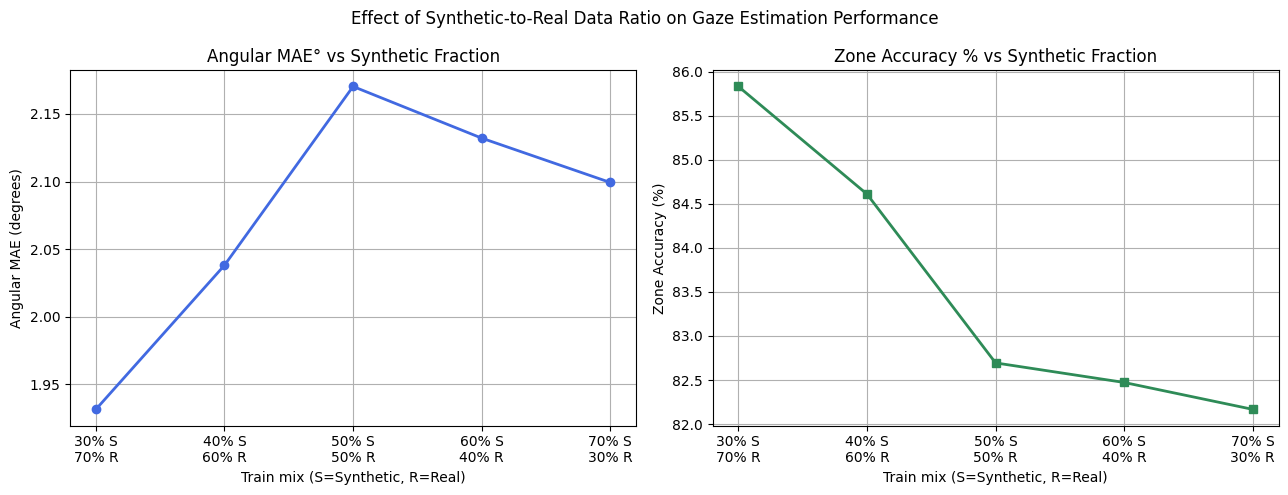

In [ ]:
SYNTH_FRACTIONS = [0.3,0.4, 0.5,0.6, 0.7]

# This keeps the test set fixed across all ratio runs.
ratio_test_loader = DataLoader(
    GazeDataset(test_df, augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

# This evaluates one trained ratio model on the fixed test set.
def evaluate_model(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            all_p.append(model(imgs.to(DEVICE)).cpu())
            all_l.append(labels)
    p = torch.cat(all_p).numpy()
    l = torch.cat(all_l).numpy()
    p_deg = p * np.array([math.degrees(THETA_MAX), math.degrees(PHI_MAX)])
    l_deg = l * np.array([math.degrees(THETA_MAX), math.degrees(PHI_MAX)])
    mae_t = np.abs(p_deg[:, 0] - l_deg[:, 0]).mean()
    mae_p = np.abs(p_deg[:, 1] - l_deg[:, 1]).mean()
    ang   = np.sqrt((p_deg[:, 0]-l_deg[:, 0])**2 + (p_deg[:, 1]-l_deg[:, 1])**2).mean()
    tz    = angle_to_zone(np.radians(l_deg[:, 0]), np.radians(l_deg[:, 1]))
    pz    = angle_to_zone(np.radians(p_deg[:, 0]), np.radians(p_deg[:, 1]))
    zacc  = (tz == pz).mean() * 100
    return mae_t, mae_p, ang, zacc


ratio_results = []

for synth_frac in SYNTH_FRACTIONS:
    print(f"\n{'='*55}")
    print(f"Ratio: {synth_frac*100:.0f}% synthetic / {(1-synth_frac)*100:.0f}% real")
    print(f"{'='*55}")

    n_train_total = len(train_idx)
    n_synth = int(n_train_total * synth_frac)
    n_real  = n_train_total - n_synth

    # Sample from original pools
    real_pool  = df_real.sample(n=min(n_real,  len(df_real)),  random_state=SEED)
    synth_pool = df_synth.sample(n=min(n_synth, len(df_synth)), random_state=SEED)
    ratio_train_df = pd.concat([real_pool, synth_pool]).sample(frac=1, random_state=SEED)

    n_val_total = len(val_idx)
    n_val_synth = int(n_val_total * synth_frac)
    n_val_real  = n_val_total - n_val_synth
    real_val_pool  = df_real.drop(real_pool.index, errors='ignore').sample(
        n=min(n_val_real,  max(len(df_real)  - len(real_pool),  0)), random_state=SEED+1)
    synth_val_pool = df_synth.drop(synth_pool.index, errors='ignore').sample(
        n=min(n_val_synth, max(len(df_synth) - len(synth_pool), 0)), random_state=SEED+1)
    ratio_val_df = pd.concat([real_val_pool, synth_val_pool]).sample(frac=1, random_state=SEED)

    r_train_loader = DataLoader(GazeDataset(ratio_train_df, augment=True),
                                batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    r_val_loader   = DataLoader(GazeDataset(ratio_val_df,   augment=False),
                                batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    r_model = build_model().to(DEVICE)
    r_opt   = torch.optim.AdamW(r_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    r_sched = torch.optim.lr_scheduler.CosineAnnealingLR(r_opt, T_max=RATIO_EPOCHS, eta_min=1e-6)
    best_r_val, best_weights, r_patience = float('inf'), None, 0

    for ep in range(1, RATIO_EPOCHS + 1):
        tr  = run_epoch(r_train_loader, r_model, criterion, r_opt)
        val = run_epoch(r_val_loader,   r_model, criterion)
        r_sched.step()
        if val < best_r_val:
            best_r_val = val
            best_weights = {k: v.clone() for k, v in r_model.state_dict().items()}
            r_patience = 0
        else:
            r_patience += 1
        if ep % 5 == 0:
            print(f"  ep {ep:3d}  tr={tr:.4f}  val={val:.4f}")
        if r_patience >= RATIO_PATIENCE:
            print(f"  Early stop ep {ep}"); break

    r_model.load_state_dict(best_weights)
    mae_t, mae_p, ang, zacc = evaluate_model(r_model, ratio_test_loader)
    ratio_results.append({
        'synth_frac': synth_frac,
        'n_synth': n_synth, 'n_real': n_real,
        'mae_theta': mae_t, 'mae_phi': mae_p,
        'angular_mae': ang, 'zone_acc': zacc
    })
    print(f"  → Angular MAE={ang:.3f}°  Zone acc={zacc:.1f}%")

ratio_df = pd.DataFrame(ratio_results)
print("\n", ratio_df.to_string(index=False))

x = [f"{int(r*100)}% S\n{int((1-r)*100)}% R" for r in SYNTH_FRACTIONS]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x, ratio_df['angular_mae'], 'o-', color='royalblue', linewidth=2)
axes[0].set_title('Angular MAE° vs Synthetic Fraction')
axes[0].set_xlabel('Train mix (S=Synthetic, R=Real)')
axes[0].set_ylabel('Angular MAE (degrees)'); axes[0].grid(True)

axes[1].plot(x, ratio_df['zone_acc'], 's-', color='seagreen', linewidth=2)
axes[1].set_title('Zone Accuracy % vs Synthetic Fraction')
axes[1].set_xlabel('Train mix (S=Synthetic, R=Real)')
axes[1].set_ylabel('Zone Accuracy (%)'); axes[1].grid(True)

plt.suptitle('Effect of Synthetic-to-Real Data Ratio on Gaze Estimation Performance')
plt.tight_layout(); plt.show()


In [17]:
%pip install -q onnx onnxruntime

## 10. ONNX Export
Install the ONNX packages, then export the saved checkpoint from Drive.

In [18]:
import os
import torch
import torch.onnx

# Export the saved checkpoint from Drive as ONNX.
PTH_PATH = f'{DRIVE_ROOT}/gaze_model_attempt2_best.pth'
ONNX_PATH = f'{DRIVE_ROOT}/gaze_model_attempt2.onnx'

if not os.path.exists(PTH_PATH):
    raise FileNotFoundError(f'Checkpoint not found in Drive: {PTH_PATH}')

# Recreate the model so the saved weights can be loaded.
export_model = build_model().to(DEVICE)
checkpoint = torch.load(PTH_PATH, map_location=DEVICE)
state_dict = checkpoint.get('model_state_dict', checkpoint) if isinstance(checkpoint, dict) else checkpoint
export_model.load_state_dict(state_dict)
export_model.eval()

dummy_input = torch.zeros(1, 3, CROP_SIZE, CROP_SIZE, device=DEVICE)

torch.onnx.export(
    export_model,
    dummy_input,
    ONNX_PATH,
    opset_version=11,
    input_names=['eye_crop'],
    output_names=['gaze'],
    dynamic_axes={
        'eye_crop': {0: 'batch_size'},
        'gaze': {0: 'batch_size'},
    },
    dynamo=False,
 )

print(f'Loaded checkpoint: {PTH_PATH}')
print(f'Saved ONNX file : {ONNX_PATH}')
print(f'File size       : {os.path.getsize(ONNX_PATH) / 1e6:.2f} MB')

try:
    import onnxruntime as ort
    session = ort.InferenceSession(ONNX_PATH)
    output = session.run(None, {'eye_crop': dummy_input.cpu().numpy()})
    print(f'ONNX check OK   : output shape {output[0].shape}')
except ImportError:
    print('Install onnxruntime for verification: pip install onnxruntime')

/tmp/ipykernel_8481/3676992537.py:22: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Loaded checkpoint: /content/drive/MyDrive/FYP_3DML/gaze_model_attempt2_best.pth
Saved ONNX file : /content/drive/MyDrive/FYP_3DML/gaze_model_attempt2.onnx
File size       : 17.32 MB
ONNX check OK   : output shape (1, 2)
